In [3]:
#load in the dataset
import pandas as pd

df = pd.read_csv('food_ingredients_and_allergens.csv')
df_2 = pd.read_csv('allergen dataset.csv')

# collapse all labels except class labels into one 'text' feature
#from sklearn.datasets import make_multilabel_classification

#multilabeller needs a set list of labels. i think i should go with the 14 allergens. Some of these allergen names need to be normalised.
allowed = {"celery", "gluten", "crustacean", "eggs", "fish",
           "lupin", "dairy", "mollusc", "mustard", "peanuts",
           "sesame", "soy", "sulphur dioxide", "sulphites", "tree nuts"}

#create a custom dictionary of allergen names
allergen_dict = {

    "ghee" : "dairy",
    "milk" : "dairy",
    "dairy" : "dairy",

    "shellfish" : "crustacean",

    "mustard" : "mustard",

    "soy" : "soy",
    "soybean" : "soy",
    "soybeans" : "soy",

    "tree nut" : "tree nuts",
    "nuts" : "tree nuts",
    "almonds" : "tree nuts",
    "walnuts" : "tree nuts",
    "pine nuts" : "tree nuts",

    "fish" : "fish",

    "wheat" : "gluten",
    "gluten" : "gluten",
    
    "celery" : "celery",

    "peanut" : "peanuts",
    "peanuts" : "peanuts",

    "eggs" : "eggs",
    "egg" : "eggs",

    "lupine" : "lupin",

}

def normalise_allergens(allergen_list):
    normalised = set() #from each row, the set of unique allergens
    allergen_list = str(allergen_list)
    allergen_list = [a.strip() for a in allergen_list.split(",")]
    #print("allergen_list: ", allergen_list)

    for allergen in allergen_list:
        allergen = allergen.lower().strip()
        #print(allergen)

        # Step 1: map synonyms
        if allergen in allergen_dict:
            #print(allergen, "is in dict")
            #print("translation: ", allergen_dict[allergen])
            normalised.add(allergen_dict[allergen]) #translate
            continue

        # Step 2: keep only if already canonical
        if allergen in allowed:
            normalised.add(allergen) #filter
    
    return list(normalised)

x = []
#x = df['Allergens'].apply(normalise_allergens)

df['Allergens'] = df['Allergens'].apply(normalise_allergens)
df_2['allergy'] = df_2['allergy'].apply(normalise_allergens)

#display(df)

#create a new dataframe

data = {
    'Food' : [],
    'Allergens' : []
}

labels = ['Food Product', 'Main Ingredient', 'Sweetener', 'Fat/Oil', 'Seasoning']

for index, row in df.iterrows():
    food_list = ""
    for label in labels:
        if(type(row[str(label)]) == str):
            food_list = food_list + (row[str(label)]) + " "
    data["Food"].append(food_list)
    data["Allergens"].append(row["Allergens"])

for index, row in df_2.iterrows():
    data["Food"].append(row['ingredient'])
    data["Allergens"].append(row["allergy"])

display(pd.DataFrame(data))


,Food,Allergens
0,Almond Cookies Almonds Sugar Butter Flour,"[gluten, dairy, tree nuts]"
1,Almond Cookies Almonds Sugar Butter Flour,"[gluten, dairy, tree nuts]"
2,Chicken Noodle Soup Chicken broth Salt,"[gluten, celery]"
3,Chicken Noodle Soup Chicken broth Salt,"[gluten, celery]"
4,Cheddar Cheese Cheese Salt,[dairy]
...,...,...
931,anchovy sauce,[fish]
932,thai fish sauce,[fish]
933,nam pla,[fish]
934,nuoc mam,[fish]


In [4]:
#encode for multi labelling
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

# Sample multi-label data
y = data["Allergens"]

# Initialize and fit MultiLabelBinarizer
mlb = MultiLabelBinarizer()
y_encoded = mlb.fit_transform(y)

food = data["Food"]

#print(y_encoded)
print(food)
#print(mlb.classes_)
#print(allowed)



['Almond Cookies Almonds Sugar Butter Flour ', 'Almond Cookies Almonds Sugar Butter Flour ', 'Chicken Noodle Soup Chicken broth Salt ', 'Chicken Noodle Soup Chicken broth Salt ', 'Cheddar Cheese Cheese Salt ', 'Ranch Dressing Buttermilk Sugar Vegetable oil Garlic, herbs ', 'Caramel Popcorn Popcorn Sugar Butter Salt ', 'Caesar Salad Romaine lettuce Olive oil Parmesan cheese ', 'Caesar Wrap Grilled chicken Caesar dressing Lettuce, Parmesan cheese ', 'Strawberry Smoothie Strawberries Honey Yogurt (milk, cultures) ', 'Cheese Pizza Cheese Tomato sauce ', 'Margherita Pizza Cheese Tomato sauce, basil ', 'Mashed Potatoes Potatoes Butter Salt, Pepper ', 'Greek Yogurt Yogurt (milk, cultures) ', 'Caesar Salad Wrap Grilled chicken Caesar dressing Lettuce, Parmesan cheese ', 'Caprese Salad Tomatoes Olive oil Mozzarella cheese, basil ', 'Berry Smoothie Mixed berries Sugar Yogurt (milk, cultures) ', 'Caesar Salad Romaine lettuce Olive oil Caesar dressing ', 'Berry Parfait Mixed berries Sugar Yogurt (

In [10]:
import numpy as np
from sklearn.datasets import make_multilabel_classification
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from skmultilearn.model_selection import iterative_train_test_split
from sklearn.multioutput import MultiOutputClassifier #Using this we can retrofit any classifier to be a multi labeller. 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, hamming_loss, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

# Apply SMOTE per minority label
# Consider skmultilearn's MLSMOTE for native multi-label support
from skmultilearn.model_selection import iterative_train_test_split

# initializing TfidfVectorizer 
vetorizar = TfidfVectorizer(
    analyzer='char', 
    ngram_range=(3, 5),      # unigrams + bigrams
    min_df=2,                # ignore very rare terms
    max_df=0.9,              # ignore extremely common terms
    max_features=20000,      # cap vocabulary size
)

# fitting the tf-idf on the given data
X = vetorizar.fit_transform(food)

print(X.shape)
print(y_encoded.shape)

# Splitting the dataset into train and test sets
X_train, y_train, X_test, y_test = iterative_train_test_split(X, y_encoded, test_size=0.2)

base_clf = LogisticRegression(
    max_iter=1000,
    C=2.0,                 # try >1.0 for less regularization
    class_weight='balanced',  # handle label imbalance
    solver='liblinear'     # often good for sparse, small-ish problems
)

# Creating the MultiOutput Classifier with Logistic Regression as the base estimator
classifier = MultiOutputClassifier(base_clf)



(936, 7457)
(936, 12)


Accuracy: 0.7712765957446809
Hamming loss: 0.0199468085106383
Micro F1: 0.8695652173913043
Macro F1: 0.847822408571516
Exact Match Ratio:  0.7712765957446809
01 Loss:  0.22872340425531915
Per-label report:
               precision    recall  f1-score   support

      celery       1.00      1.00      1.00         8
  crustacean       0.90      1.00      0.95         9
       dairy       0.93      0.95      0.94        57
        eggs       1.00      0.62      0.77         8
        fish       0.92      0.65      0.76        17
      gluten       0.66      0.79      0.72        29
       lupin       1.00      1.00      1.00         6
     mustard       0.90      1.00      0.95         9
     peanuts       0.90      1.00      0.95         9
      sesame       1.00      0.75      0.86         4
         soy       0.92      0.86      0.89        14
   tree nuts       0.33      0.50      0.40         2

   micro avg       0.87      0.87      0.87       172
   macro avg       0.87      0.84  

c:\Users\enara\anaconda3\envs\ocr\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\enara\anaconda3\envs\ocr\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\enara\anaconda3\envs\ocr\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


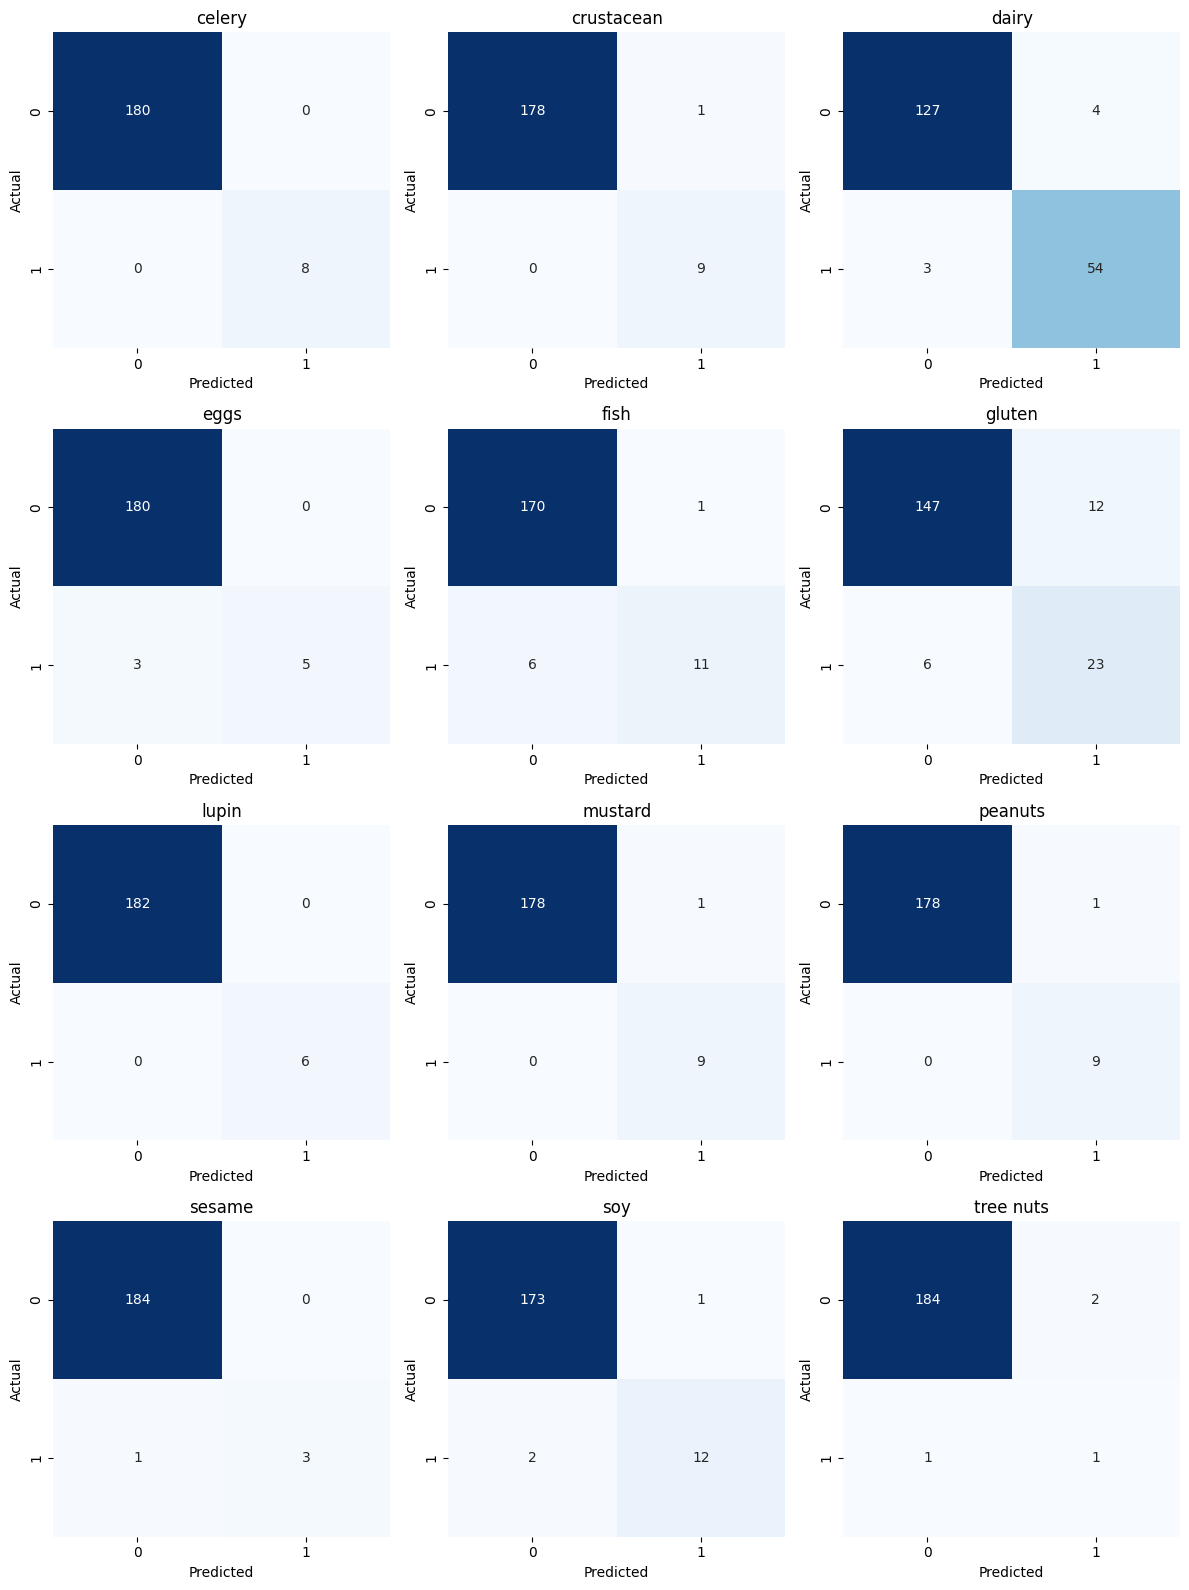

In [11]:
# Fitting the classifier on the training data
classifier.fit(X_train, y_train)

# Making predictions on the test set
predictions = classifier.predict(X_test)
proba = classifier.predict_proba(X_test)

# Evaluate the model, for example, using accuracy score
accuracy = classifier.score(X_test, y_test)
print("Accuracy:", accuracy)

y_pred = classifier.predict(X_test)

print("Hamming loss:", hamming_loss(y_test, y_pred))
print("Micro F1:", f1_score(y_test, y_pred, average='micro'))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("Exact Match Ratio: ", np.all(y_pred == y_test, axis=1).mean())
print("01 Loss: ", np.any(y_test != y_pred, axis=1).mean())
print("Per-label report:\n", classification_report(y_test, y_pred, target_names=mlb.classes_))


print(mlb.classes_)

from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cms = multilabel_confusion_matrix(y_test, y_pred)
print(cms.shape)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

labels = mlb.classes_ 

n_labels = len(labels)
cols = 3
rows = int(np.ceil(n_labels / cols))

fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))

axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < n_labels:
        sns.heatmap(
            cms[i],
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=ax
        )
        ax.set_title(labels[i])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()



In [8]:
new_sentences = ["Salmon Grilled Salmon, Green Peas Served With Mixed Salad"]
new_sentence_tfidf = vetorizar.transform(new_sentences)
probas = classifier.predict_proba(new_sentence_tfidf)

predicted_sentences = classifier.predict(new_sentence_tfidf)
proba_sentence = classifier.predict_proba(new_sentence_tfidf)
#print(predicted_sentences)
#print(mlb.classes_)

decoded = [mlb.classes_[i] for i, val in enumerate(predicted_sentences[0]) if (val == 1).any()]
print(decoded)
print(proba_sentence)



['fish']
[array([[0.92542513, 0.07457487]]), array([[0.90396221, 0.09603779]]), array([[0.81673753, 0.18326247]]), array([[0.92656838, 0.07343162]]), array([[0.35100366, 0.64899634]]), array([[0.85046788, 0.14953212]]), array([[0.95889074, 0.04110926]]), array([[0.93671301, 0.06328699]]), array([[0.94190657, 0.05809343]]), array([[0.96492574, 0.03507426]]), array([[0.80131637, 0.19868363]]), array([[0.92616657, 0.07383343]])]
